# Welcome to the SOCat Interactive Notebook

This is an in-browser Python environment for exploring the SOCat catalog and trying small ideas without installing anything locally.

For the SOCat catalog itself, see the **λ vs. T<sub>eff</sub>** notebook (worked example) or **more** (placeholder for future tutorials). This notebook covers the basics: what JupyterLite is and how to do simple NumPy / Matplotlib work in it.

## How does this work?

This is a **JupyterLite** notebook — a fully functional Jupyter environment that runs **entirely in your web browser**, with no server, no installation, and no account.

Under the hood:

- **Python via WebAssembly.** The Python interpreter is [Pyodide](https://pyodide.org/), a port of CPython compiled to WebAssembly and run by your browser's JavaScript engine. Every cell you execute runs locally in your tab — never on a remote machine.
- **Pre-loaded scientific stack.** `pandas`, `numpy`, and `matplotlib` are bundled with this build. To add any other pure-Python or Pyodide-compatible package on the fly, run `%pip install <name>` (or `await micropip.install('<name>')`).
- **Network access through `fetch`.** Pyodide has no native TCP sockets, so libraries like `requests` and `urllib` can't make HTTP requests directly. Use `from pyodide.http import pyfetch` instead — the imports cell below uses this to pull the SOCat catalog live from the website.
- **Your work autosaves in the browser.** Edited notebooks and any files you create are stored in your browser's IndexedDB. To wipe everything and return to the original tutorial state, use **Help → Clear Browser Data** in the menu bar above (or just open this page in a private/incognito window).
- **No server side at all.** The whole site is a static collection of JS/WASM/HTML served from GitHub Pages and reverse-proxied under `stellarobliquity.com` by a Cloudflare Worker. After the first load you can use this notebook **offline** — the kernel never leaves your tab.

When you press **Shift + Enter**, your browser runs the Python code locally. The plots you make never travel over the network.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Use STIX (Times-like) font — matplotlib-bundled, no download needed
plt.rcParams['font.family']      = 'STIXGeneral'
plt.rcParams['mathtext.fontset'] = 'stix'

# A tiny NumPy demo: 1000 samples from a standard normal, simple statistics.
rng = np.random.default_rng(seed=42)
x = rng.standard_normal(1000)

print(f'Sample size : {x.size}')
print(f'Mean        : {x.mean():+.3f}')
print(f'Std dev     : {x.std():+.3f}')
print(f'Min / Max   : {x.min():+.3f} / {x.max():+.3f}')

Sample size : 1000
Mean        : -0.029
Std dev     : +0.989
Min / Max   : -3.648 / +3.179


## Matplotlib demo — histogram + Gaussian overlay

A quick sanity check: plot the histogram of the samples above and overlay the expected $\mathcal{N}(0,1)$ density.

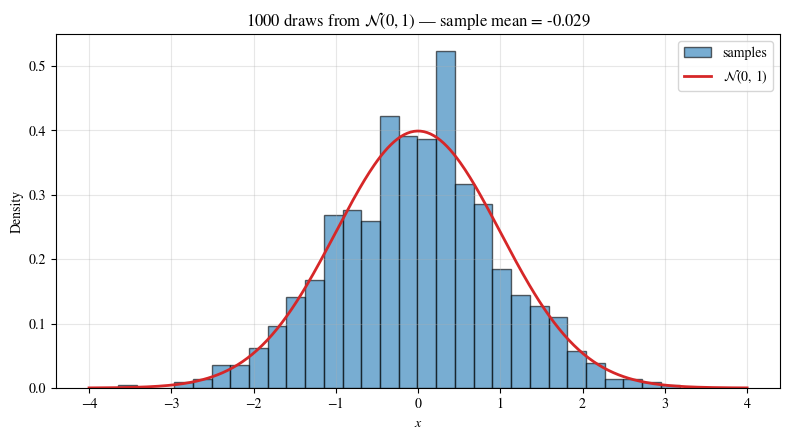

In [2]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# histogram (density-normalised)
ax.hist(x, bins=30, density=True, alpha=0.6, color='C0', edgecolor='black', label='samples')

# overlay analytic N(0, 1) PDF
xx = np.linspace(-4, 4, 400)
ax.plot(xx, np.exp(-0.5 * xx**2) / np.sqrt(2 * np.pi),
        color='C3', lw=2, label=r'$\mathcal{N}(0,\,1)$')

ax.set_xlabel(r'$x$')
ax.set_ylabel('Density')
ax.set_title(f'1000 draws from $\\mathcal{{N}}(0,1)$ — sample mean = {x.mean():+.3f}')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()